# Évaluation du modèle Camembert NER


Ce notebook présente l'évaluation du modèle NER Camembert pour la détection des entités suivantes :

- **O** : Aucun intérêt, non lié à une ville.
- **B-DEP** : Début d'une ville de départ.
- **B-ARR** : Début d'une ville de destination.
- **I-DEP** : Continuation d'une ville de départ.
- **I-ARR** : Continuation d'une ville de destination.


## Visualisation des métriques de performance

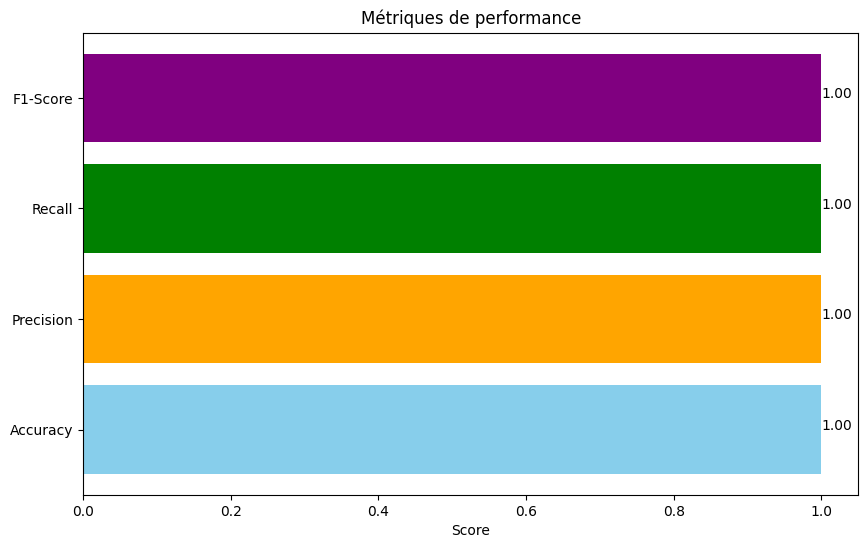

In [1]:

import matplotlib.pyplot as plt
import json

metrics = json.loads('''{"Accuracy": 1.0, "Precision": 1.0, "Recall": 1.0, "F1-Score": 1.0}''')

plt.figure(figsize=(10, 6))
plt.barh(list(metrics.keys()), list(metrics.values()), color=['skyblue', 'orange', 'green', 'purple'])
plt.xlabel("Score")
plt.title("Métriques de performance")
for i, (key, value) in enumerate(metrics.items()):
    plt.text(value, i, f"{value:.2f}")
plt.show()


## Matrice de confusion


La matrice de confusion compare les prédictions du modèle avec les étiquettes réelles :

- Les **lignes** correspondent aux étiquettes réelles (ce que le modèle devait prédire).
- Les **colonnes** correspondent aux étiquettes prédites (ce que le modèle a réellement prédit).
- La diagonale principale montre les prédictions correctes.


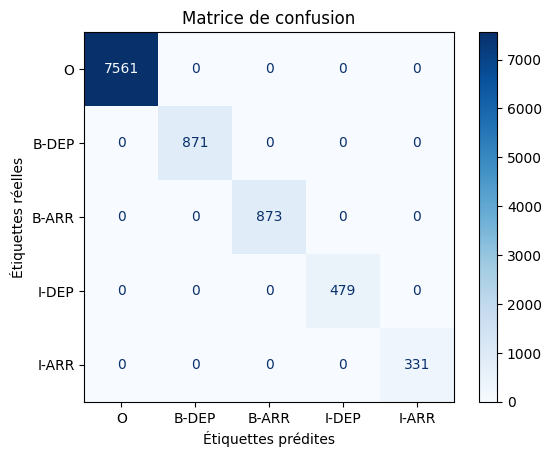

In [2]:

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_true_labels = json.loads('''[0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0]''')
all_predicted_labels = json.loads('''[0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0]''')

classes = ['O', 'B-DEP', 'B-ARR', 'I-DEP', 'I-ARR']
cm = confusion_matrix(all_true_labels, all_predicted_labels, labels=range(len(classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion")
plt.xlabel("Étiquettes prédites")
plt.ylabel("Étiquettes réelles")
plt.show()


## Distribution des classes


Ce graphique montre la répartition des classes dans les étiquettes réelles et prédites :

- **Axe X** : Les différentes classes (`O`, `B-DEP`, etc.).
- **Axe Y** : Le nombre de tokens dans chaque classe.
- Les barres permettent de comparer la répartition entre les étiquettes réelles et prédites.


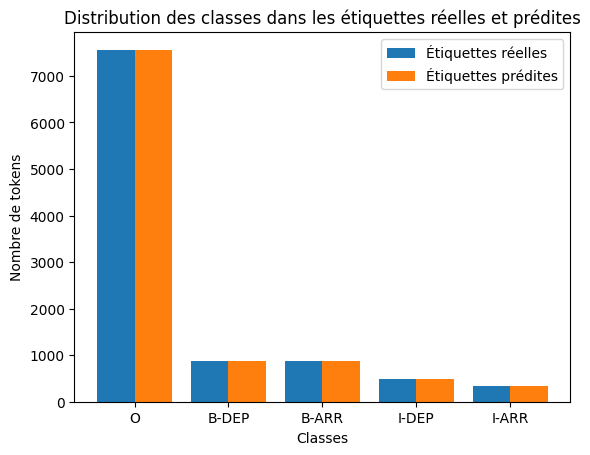

In [3]:

from collections import Counter

true_counts = Counter(all_true_labels)
predicted_counts = Counter(all_predicted_labels)

true_values = [true_counts.get(i, 0) for i in range(len(classes))]
predicted_values = [predicted_counts.get(i, 0) for i in range(len(classes))]

x = range(len(classes))
plt.bar(x, true_values, width=0.4, label="Étiquettes réelles", align="center")
plt.bar([p + 0.4 for p in x], predicted_values, width=0.4, label="Étiquettes prédites", align="center")
plt.xticks([p + 0.2 for p in x], classes)
plt.xlabel("Classes")
plt.ylabel("Nombre de tokens")
plt.legend()
plt.title("Distribution des classes dans les étiquettes réelles et prédites")
plt.show()


## F1-Score par classe


Le F1-score par classe combine précision et rappel pour chaque classe :

- **Axe X** : Les différentes classes (`O`, `B-DEP`, etc.).
- **Axe Y** : Le score F1 (entre 0 et 1).
- Plus le score F1 est proche de 1, meilleures sont les prédictions pour cette classe.


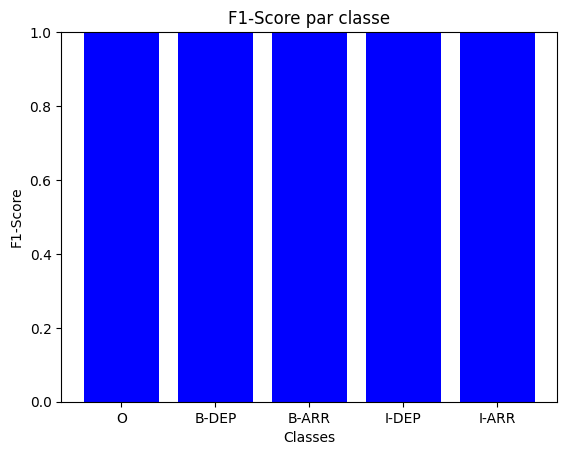

In [4]:

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

report = classification_report(all_true_labels, all_predicted_labels, target_names=classes, zero_division=0, output_dict=True)
f1_scores = [report[cls]["f1-score"] for cls in classes]

plt.bar(classes, f1_scores, color='blue')
plt.xlabel("Classes")
plt.ylabel("F1-Score")
plt.title("F1-Score par classe")
plt.ylim(0, 1)
plt.show()


## Courbe ROC


La courbe ROC évalue la capacité du modèle à discriminer entre les classes.

- **Axe X** : Taux de faux positifs (FPR).
- **Axe Y** : Taux de vrais positifs (TPR).
- Une courbe proche de la diagonale indique une mauvaise séparation des classes.
- L'AUC (Area Under Curve) mesure l'efficacité globale (1 = parfait, 0.5 = aléatoire).


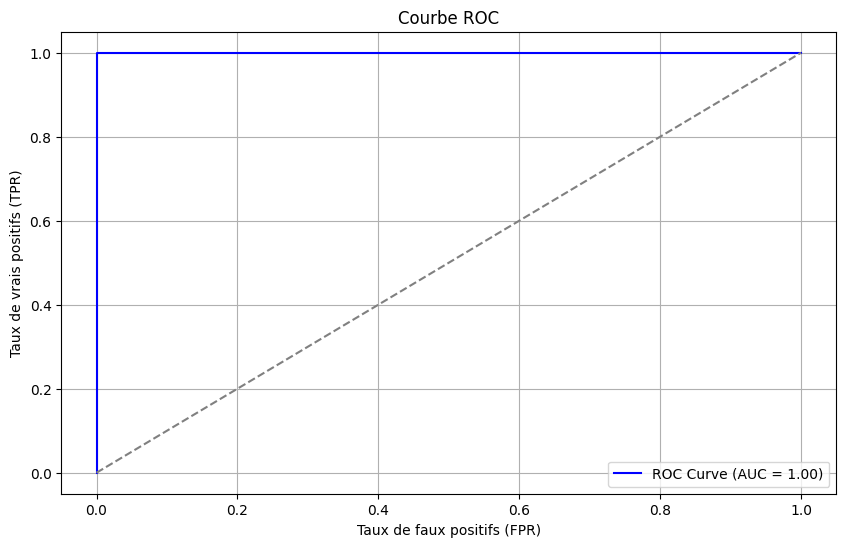

In [5]:

from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Conversion des étiquettes en un format binaire pour le ROC
true_labels_bin = np.array([1 if label in [1, 3] else 0 for label in all_true_labels])  # B-DEP/I-DEP comme positifs
predicted_labels_bin = np.array([1 if label in [1, 3] else 0 for label in all_predicted_labels])

try:
    fpr, tpr, _ = roc_curve(true_labels_bin, predicted_labels_bin)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("Taux de faux positifs (FPR)")
    plt.ylabel("Taux de vrais positifs (TPR)")
    plt.title("Courbe ROC")
    plt.legend()
    plt.grid()
    plt.show()
except ValueError as e:
    print(f"Erreur lors de la génération de la courbe ROC : {e}")


In [6]:

import json

# Charger les données nécessaires pour le notebook
test_texts = json.loads('''["Elle cherche un itin\u00e9raire jusqu'\u00e0 Nice \u00e0 Paris", "Je veux aller de Biarritz \u00e0 Marseille", "Il pr\u00e9voit de partir de Lyon \u00e0 Toulouse demain", "Nous r\u00e9servons un billet pour un trajet de Bordeaux \u00e0 Nantes", "Elle va prendre le train de Strasbourg \u00e0 Lille", "Il part de Montpellier pour aller \u00e0 Lyon", "Elle cherche un vol de Paris \u00e0 Nice", "Il prend l'avion pour un trajet entre Lyon et Marseille", "Nous pr\u00e9voyons de partir de Toulouse pour visiter Bordeaux", "Je cherche un itin\u00e9raire en train de Nantes \u00e0 Rennes", "Nous devons partir demain matin de Marseille \u00e0 Strasbourg", "Je dois rejoindre mes amis de Bordeaux \u00e0 Paris", "Il a pr\u00e9vu de voyager de Lille \u00e0 Toulouse", "Je pars de Nice pour un s\u00e9jour \u00e0 Paris", "Nous avons r\u00e9serv\u00e9 un billet de Rennes \u00e0 Lyon", "Ils veulent un trajet de Marseille \u00e0 Bordeaux", "Elle se rendra de Strasbourg \u00e0 Lille en train", "Nous allons en voiture de Toulouse \u00e0 Montpellier", "Il cherche un vol de Bordeaux \u00e0 Paris", "Elle a pr\u00e9vu un trajet de Marseille \u00e0 Nantes", "Ils prennent un train de Rennes \u00e0 Lyon ce soir", "Nous partons demain matin de Paris \u00e0 Lille", "Il a achet\u00e9 un billet de Toulouse \u00e0 Bordeaux", "Elle prend l'avion de Nice \u00e0 Lyon la semaine prochaine", "Nous cherchons un trajet de Nantes \u00e0 Paris", "Il voyage de Lille \u00e0 Marseille pour un \u00e9v\u00e9nement", "Elle prend le train de Rennes \u00e0 Strasbourg", "Je pr\u00e9vois de partir de Paris pour aller \u00e0 Lyon", "Nous cherchons un itin\u00e9raire de Toulouse \u00e0 Marseille", "Elle pr\u00e9voit un trajet de Lille \u00e0 Nice", "Il part en train de Rennes \u00e0 Paris", "Nous allons voyager de Marseille \u00e0 Toulouse", "Je cherche un billet de train de Bordeaux \u00e0 Nantes", "Elle a r\u00e9serv\u00e9 un vol de Paris \u00e0 Marseille", "Il doit rejoindre un client de Strasbourg \u00e0 Lyon", "Nous avons pr\u00e9vu de partir de Lille \u00e0 Rennes", "Je dois prendre un avion de Marseille \u00e0 Paris", "Elle part de Lyon pour visiter Toulouse", "Nous cherchons un itin\u00e9raire de train de Bordeaux \u00e0 Nice", "Il pr\u00e9voit de partir de Paris \u00e0 Rennes", "Elle veut prendre un train de Lille \u00e0 Marseille", "Nous pr\u00e9voyons un voyage de Rennes \u00e0 Paris", "Je vais voyager de Toulouse \u00e0 Lille", "Elle doit rejoindre des coll\u00e8gues de Paris \u00e0 Lyon", "Nous cherchons un trajet en train de Bordeaux \u00e0 Marseille", "Il prend un avion de Nice \u00e0 Strasbourg", "Elle part de Rennes pour visiter Nantes", "Nous r\u00e9servons un billet de Paris \u00e0 Toulouse", "Il pr\u00e9voit un vol de Lyon \u00e0 Lille", "Elle prend un train de Bordeaux \u00e0 Marseille", "Nous cherchons un vol de Toulouse \u00e0 Rennes", "Je pr\u00e9vois de prendre un train de Paris \u00e0 Nice", "Nous partons demain de Lille \u00e0 Bordeaux", "Elle veut r\u00e9server un billet de Rennes \u00e0 Lyon", "Je dois aller de Paris \u00e0 Nantes", "Elle pr\u00e9voit un voyage de Marseille \u00e0 Lille", "Nous avons pris un billet de Toulouse \u00e0 Bordeaux", "Il part en voiture de Lille \u00e0 Paris", "Je prends un vol de Marseille \u00e0 Strasbourg", "Elle part en train de Bordeaux \u00e0 Rennes", "Nous r\u00e9servons un billet de Lyon \u00e0 Marseille", "Elle veut voyager de Toulouse \u00e0 Paris", "Nous cherchons un itin\u00e9raire de train de Rennes \u00e0 Lille", "Il prend un avion de Marseille \u00e0 Nantes", "Elle pr\u00e9voit de partir de Paris \u00e0 Rennes", "Nous allons de Lyon \u00e0 Bordeaux demain", "Il prend un train de Lille \u00e0 Toulouse", "Elle cherche un trajet de Rennes \u00e0 Marseille", "Nous pr\u00e9voyons un voyage de Bordeaux \u00e0 Lyon", "Je dois aller de Paris \u00e0 Marseille demain", "Elle pr\u00e9voit de rejoindre ses amis de Lille \u00e0 Toulouse", "Il part de Rennes pour un \u00e9v\u00e9nement \u00e0 Paris", "Nous r\u00e9servons un billet de Marseille \u00e0 Lille", "Elle prend un avion de Toulouse \u00e0 Lyon", "Je pars de Paris pour visiter Rennes", "Nous cherchons un trajet de train de Lille \u00e0 Bordeaux", "Il voyage de Rennes \u00e0 Nice", "Je cherche un billet de train de Paris \u00e0 Marseille", "Elle pr\u00e9voit de voyager de Bordeaux \u00e0 Lyon demain", "Nous avons un vol pr\u00e9vu de Toulouse \u00e0 Nice", "Il prend le bus de Rennes \u00e0 Strasbourg ce soir", "Elle veut un itin\u00e9raire de train de Lille \u00e0 Paris", "Je dois partir de Lyon pour une r\u00e9union \u00e0 Marseille", "Nous avons un billet de train pour un voyage de Nantes \u00e0 Paris", "Elle pr\u00e9voit de prendre le train de Marseille \u00e0 Lyon", "Je cherche un itin\u00e9raire de Bordeaux \u00e0 Nice", "Il pr\u00e9voit de partir de Rennes pour visiter Lille", "Elle prend un avion de Toulouse \u00e0 Strasbourg", "Nous allons voyager de Lyon \u00e0 Bordeaux demain", "Il part en train de Paris \u00e0 Nice", "Elle veut r\u00e9server un billet de Rennes \u00e0 Marseille", "Je pr\u00e9vois de prendre le train de Nantes \u00e0 Lyon", "Nous avons un vol pr\u00e9vu de Lille \u00e0 Toulouse", "Elle doit rejoindre des amis de Marseille \u00e0 Paris", "Il pr\u00e9voit de voyager de Bordeaux \u00e0 Strasbourg", "Nous cherchons un itin\u00e9raire de Rennes \u00e0 Toulouse", "Elle prend un billet pour un trajet de Nice \u00e0 Bordeaux", "Je veux partir de Lyon pour un \u00e9v\u00e9nement \u00e0 Paris", "Il partira demain de Toulouse \u00e0 Lille", "Elle prend un train de Rennes \u00e0 Lyon", "Nous r\u00e9servons un vol de Marseille \u00e0 Nice", "Il veut voyager de Paris \u00e0 Strasbourg", "Elle pr\u00e9voit un trajet de Bordeaux \u00e0 Toulouse", "Nous avons un billet pour un voyage de Lille \u00e0 Lyon", "Elle veut rejoindre ses coll\u00e8gues de Rennes \u00e0 Paris", "Je dois partir de Marseille pour un s\u00e9jour \u00e0 Bordeaux", "Il prend le bus de Nice \u00e0 Toulouse ce soir", "Elle pr\u00e9voit de voyager de Lyon \u00e0 Rennes demain", "Nous r\u00e9servons un vol de Paris \u00e0 Lille", "Elle partira en train de Bordeaux \u00e0 Marseille", "Il pr\u00e9voit de rejoindre des amis de Rennes \u00e0 Nice", "Nous avons un trajet pr\u00e9vu de Toulouse \u00e0 Lyon", "Elle doit partir de Paris pour un \u00e9v\u00e9nement \u00e0 Marseille", "Je cherche un itin\u00e9raire de Rennes \u00e0 Bordeaux", "Il part de Lille pour un s\u00e9jour \u00e0 Strasbourg", "Elle prend un avion de Nice \u00e0 Lyon la semaine prochaine", "Nous pr\u00e9voyons de prendre le train de Bordeaux \u00e0 Lille", "Elle veut rejoindre des amis de Paris \u00e0 Toulouse", "Nous avons r\u00e9serv\u00e9 un billet de Marseille \u00e0 Rennes", "Il pr\u00e9voit de partir de Lyon pour visiter Lille", "Je pars de Rennes pour un voyage \u00e0 Paris", "Elle prend un billet de train de Toulouse \u00e0 Nice", "Nous r\u00e9servons un vol de Bordeaux \u00e0 Strasbourg", "Il cherche un itin\u00e9raire de Paris \u00e0 Lyon", "Elle pr\u00e9voit de rejoindre ses coll\u00e8gues de Lille \u00e0 Marseille", "Nous devons partir de Nice pour un \u00e9v\u00e9nement \u00e0 Rennes", "Je cherche un vol de Toulouse \u00e0 Paris", "Elle a pr\u00e9vu de voyager de Bordeaux \u00e0 Marseille", "Nous avons un billet pour un trajet de Lyon \u00e0 Strasbourg", "Elle veut partir de Lille pour visiter Rennes", "Je pr\u00e9vois de prendre le train de Marseille \u00e0 Paris", "Il prend un bus de Bordeaux \u00e0 Nice ce soir", "Elle pr\u00e9voit un itin\u00e9raire de Rennes \u00e0 Toulouse", "Nous allons partir de Lyon pour un \u00e9v\u00e9nement \u00e0 Lille", "Elle veut prendre un billet de train de Nice \u00e0 Paris", "Il pr\u00e9voit de rejoindre des amis de Marseille \u00e0 Rennes", "Je cherche un trajet de Toulouse \u00e0 Lyon", "Elle prend un avion de Bordeaux \u00e0 Paris", "Nous partons en train de Lille \u00e0 Nice", "Il pr\u00e9voit de voyager de Rennes \u00e0 Strasbourg", "Elle veut prendre un vol de Lyon \u00e0 Toulouse", "Je cherche un billet de train de Marseille \u00e0 Lille", "Nous avons r\u00e9serv\u00e9 un vol de Paris \u00e0 Bordeaux", "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Rennes", "Il pr\u00e9voit un voyage de Toulouse \u00e0 Marseille", "Nous avons un trajet de Lille \u00e0 Paris pr\u00e9vu", "Elle veut rejoindre ses amis de Rennes \u00e0 Lyon", "Je pars de Bordeaux pour visiter Marseille", "Il pr\u00e9voit de prendre un bus de Lyon \u00e0 Nice", "Elle a r\u00e9serv\u00e9 un billet pour un trajet de Paris \u00e0 Toulouse", "Nous cherchons un vol de Marseille \u00e0 Strasbourg", "Elle veut voyager de Lille \u00e0 Bordeaux", "Je cherche un billet de train de Rennes \u00e0 Marseille", "Nous pr\u00e9voyons de prendre un vol de Toulouse \u00e0 Paris", "Elle pr\u00e9voit un trajet de Nice \u00e0 Lyon", "Il part de Bordeaux pour un s\u00e9jour \u00e0 Lille", "Elle prend un billet pour un trajet de Rennes \u00e0 Nice", "Nous avons r\u00e9serv\u00e9 un vol de Paris \u00e0 Lyon", "Il cherche un itin\u00e9raire de Marseille \u00e0 Toulouse", "Elle veut partir de Strasbourg pour un s\u00e9jour \u00e0 Rennes", "Je pr\u00e9vois de prendre le bus de Nice \u00e0 Paris", "Elle pr\u00e9voit de rejoindre ses amis de Lille \u00e0 Bordeaux", "Nous r\u00e9servons un vol de Toulouse \u00e0 Lyon", "Il veut partir de Rennes pour visiter Marseille", "Je prends un billet de train de Bordeaux \u00e0 Strasbourg", "Elle veut voyager de Lyon \u00e0 Paris", "Nous avons un billet pour un trajet de Lille \u00e0 Nice", "Elle doit rejoindre des coll\u00e8gues de Rennes \u00e0 Bordeaux", "Je cherche un vol de Marseille \u00e0 Paris", "Il pr\u00e9voit de partir de Lyon pour un \u00e9v\u00e9nement \u00e0 Toulouse", "Elle prend un train de Bordeaux \u00e0 Lille", "Nous cherchons un vol de Paris \u00e0 Strasbourg", "Elle veut rejoindre des amis de Nice \u00e0 Lyon", "Il pr\u00e9voit de voyager de Toulouse \u00e0 Bordeaux", "Je pars de Rennes pour visiter Marseille", "Elle pr\u00e9voit un trajet de Lyon \u00e0 Paris", "Nous avons r\u00e9serv\u00e9 un billet de Marseille \u00e0 Nice", "Il cherche un itin\u00e9raire de Bordeaux \u00e0 Toulouse", "Elle veut rejoindre ses amis de Lille \u00e0 Rennes", "Nous pr\u00e9voyons de partir de Paris pour visiter Lyon", "Elle prend un vol de Nice \u00e0 Strasbourg", "Je dois aller de Marseille \u00e0 Bordeaux", "Il veut un billet de train de Rennes \u00e0 Toulouse", "Elle pr\u00e9voit de voyager de Lyon \u00e0 Marseille demain", "Nous cherchons un vol de Paris \u00e0 Nice", "Elle pr\u00e9voit un trajet de Bordeaux \u00e0 Rennes", "Nous partons demain de Toulouse \u00e0 Lille", "Il prend un billet pour un trajet de Paris \u00e0 Strasbourg", "Elle pr\u00e9voit un voyage de Marseille \u00e0 Lyon", "Je cherche un itin\u00e9raire de train de Bordeaux \u00e0 Paris", "Nous avons un billet pour un trajet de Lille \u00e0 Marseille", "Elle veut voyager de Rennes \u00e0 Toulouse", "Il pr\u00e9voit de partir de Paris pour un \u00e9v\u00e9nement \u00e0 Nice", "Elle prend un vol de Bordeaux \u00e0 Lyon", "Nous avons r\u00e9serv\u00e9 un billet de Marseille \u00e0 Strasbourg", "Elle pr\u00e9voit de partir de Lille \u00e0 Paris", "Je cherche un vol de Toulouse \u00e0 Rennes", "Nous partons en train de Bordeaux \u00e0 Lyon", "Elle veut prendre un vol de Nice \u00e0 Toulouse", "Il pr\u00e9voit de rejoindre des amis de Paris \u00e0 Bordeaux", "Nous avons r\u00e9serv\u00e9 un billet de Lyon \u00e0 Nice", "Elle veut partir de Marseille pour un s\u00e9jour \u00e0 Strasbourg", "Je cherche un billet de train de Lille \u00e0 Rennes", "Nous pr\u00e9voyons de prendre le bus de Paris \u00e0 Marseille", "Elle pr\u00e9voit un trajet de Bordeaux \u00e0 Toulouse", "Il part de Nice pour un \u00e9v\u00e9nement \u00e0 Lyon", "Elle prend un billet pour un trajet de Rennes \u00e0 Bordeaux", "Nous r\u00e9servons un vol de Paris \u00e0 Strasbourg", "Il cherche un itin\u00e9raire de Marseille \u00e0 Nice", "Elle veut partir de Toulouse pour un s\u00e9jour \u00e0 Lille", "Nous pr\u00e9voyons de voyager de Rennes \u00e0 Paris", "Elle prend un vol de Bordeaux \u00e0 Marseille", "Je pr\u00e9vois de partir de Lyon pour visiter Toulouse", "Elle veut rejoindre des coll\u00e8gues de Nice \u00e0 Paris", "Nous cherchons un vol de Lille \u00e0 Bordeaux", "Il pr\u00e9voit de voyager de Marseille \u00e0 Lyon", "Elle prend un billet de train de Rennes \u00e0 Toulouse", "Nous avons un trajet de Paris \u00e0 Nice pr\u00e9vu", "Il pr\u00e9voit un voyage de Marseille \u00e0 Rennes", "Elle prend un billet pour un trajet de Lille \u00e0 Lyon", "Nous avons un vol de Bordeaux \u00e0 Toulouse", "Elle veut rejoindre des amis de Paris \u00e0 Marseille", "Il cherche un itin\u00e9raire de Lyon \u00e0 Strasbourg", "Elle pr\u00e9voit de prendre le train de Rennes \u00e0 Bordeaux", "Nous partons en train de Toulouse \u00e0 Nice", "Elle veut prendre un billet de Marseille \u00e0 Paris", "Il pr\u00e9voit de partir de Lille pour visiter Lyon", "Elle prend un avion de Bordeaux \u00e0 Strasbourg", "Nous avons r\u00e9serv\u00e9 un billet de Paris \u00e0 Nice", "Elle part de Rennes pour un s\u00e9jour \u00e0 Toulouse", "Il cherche un vol de Marseille \u00e0 Lyon", "Elle pr\u00e9voit de voyager de Bordeaux \u00e0 Paris", "Nous r\u00e9servons un vol de Lille \u00e0 Marseille", "Elle veut partir de Toulouse pour un \u00e9v\u00e9nement \u00e0 Rennes", "Nous pr\u00e9voyons un trajet de Nice \u00e0 Lyon", "Elle prend un billet pour un voyage de Paris \u00e0 Bordeaux", "Il pr\u00e9voit de rejoindre des amis de Marseille \u00e0 Nice", "Elle veut voyager de Lille \u00e0 Toulouse", "Nous avons un vol de Rennes \u00e0 Lyon", "Elle prend un billet pour un trajet de Bordeaux \u00e0 Strasbourg", "Nous cherchons un vol de Paris \u00e0 Toulouse", "Elle pr\u00e9voit de partir de Marseille pour visiter Rennes", "Il prend un avion de Lyon \u00e0 Lille", "Elle pr\u00e9voit de voyager de Nice \u00e0 Paris", "Nous partons en train de Bordeaux \u00e0 Marseille", "Elle prend un vol pour un trajet de Toulouse \u00e0 Strasbourg", "Nous avons r\u00e9serv\u00e9 un billet de Lille \u00e0 Rennes", "Elle veut voyager de Marseille \u00e0 Lyon", "Il cherche un itin\u00e9raire de Paris \u00e0 Bordeaux", "Elle prend un billet pour un trajet de Rennes \u00e0 Nice", "Nous avons un vol de Toulouse \u00e0 Lille", "Elle veut rejoindre des amis de Lyon \u00e0 Marseille", "Nous cherchons un vol de Bordeaux \u00e0 Paris", "Elle part de Nice pour un s\u00e9jour \u00e0 Lyon", "Nous pr\u00e9voyons de partir de Rennes pour visiter Bordeaux", "Elle prend un billet de train pour un trajet de Toulouse \u00e0 Paris", "Nous avons r\u00e9serv\u00e9 un vol de Lille \u00e0 Lyon", "Elle veut voyager de Marseille \u00e0 Bordeaux", "Il pr\u00e9voit un trajet de Paris \u00e0 Rennes", "Elle prend un avion pour un voyage de Nice \u00e0 Toulouse", "Nous partons en train de Bordeaux \u00e0 Lyon", "Elle pr\u00e9voit de voyager de Lille \u00e0 Strasbourg", "Nous avons r\u00e9serv\u00e9 un billet de Paris \u00e0 Marseille", "Elle veut rejoindre ses coll\u00e8gues de Rennes \u00e0 Bordeaux", "Nous cherchons un vol de Toulouse \u00e0 Lyon", "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Bordeaux", "Il pr\u00e9voit un trajet de Lille \u00e0 Paris", "Elle prend un billet pour un voyage de Marseille \u00e0 Toulouse", "Nous avons un vol de Rennes \u00e0 Nice", "Elle pr\u00e9voit de rejoindre des amis de Paris \u00e0 Lyon", "Nous pr\u00e9voyons de partir de Bordeaux pour visiter Marseille", "Elle prend un billet de train pour un trajet de Toulouse \u00e0 Rennes", "Nous avons r\u00e9serv\u00e9 un vol de Lille \u00e0 Marseille", "Elle veut voyager de Lyon \u00e0 Paris", "Il pr\u00e9voit un trajet de Rennes \u00e0 Strasbourg", "Elle prend un avion pour un voyage de Bordeaux \u00e0 Lille", "Nous partons en train de Nice \u00e0 Toulouse", "Elle pr\u00e9voit de voyager de Paris \u00e0 Bordeaux", "Nous avons r\u00e9serv\u00e9 un billet de Marseille \u00e0 Lyon", "Elle veut rejoindre des coll\u00e8gues de Toulouse \u00e0 Rennes", "Nous cherchons un vol de Lille \u00e0 Nice", "Elle partira de Lyon pour un \u00e9v\u00e9nement \u00e0 Bordeaux", "Nous pr\u00e9voyons de partir de Rennes pour visiter Paris", "Elle prend un billet de train pour un trajet de Toulouse \u00e0 Strasbourg", "Nous avons un vol de Bordeaux \u00e0 Marseille", "Elle veut voyager de Nice \u00e0 Rennes", "Il pr\u00e9voit un trajet de Paris \u00e0 Lille", "Elle prend un avion pour un voyage de Marseille \u00e0 Lyon", "Nous partons en train de Toulouse \u00e0 Bordeaux", "Elle pr\u00e9voit de voyager de Rennes \u00e0 Nice", "Nous avons r\u00e9serv\u00e9 un billet de Lyon \u00e0 Paris", "Elle veut rejoindre des coll\u00e8gues de Bordeaux \u00e0 Marseille", "Nous cherchons un vol de Lille \u00e0 Rennes", "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Toulouse", "Nous pr\u00e9voyons de partir de Paris pour visiter Lyon", "Elle prend un billet de train pour un trajet de Bordeaux \u00e0 Nice", "Nous avons un vol de Marseille \u00e0 Lille", "Elle veut voyager de Toulouse \u00e0 Strasbourg", "Il pr\u00e9voit un trajet de Rennes \u00e0 Paris", "Elle prend un avion pour un voyage de Lyon \u00e0 Marseille", "Nous partons en train de Bordeaux \u00e0 Lille", "Elle pr\u00e9voit de voyager de Nice \u00e0 Toulouse", "Nous avons r\u00e9serv\u00e9 un billet de Paris \u00e0 Rennes", "Elle veut rejoindre des amis de Marseille \u00e0 Lyon", "Nous cherchons un vol de Toulouse \u00e0 Nice", "Elle partira de Bordeaux pour un \u00e9v\u00e9nement \u00e0 Lyon", "Nous pr\u00e9voyons de partir de Lille pour visiter Paris", "Elle prend un billet de train pour un trajet de Marseille \u00e0 Bordeaux", "Nous avons un vol de Rennes \u00e0 Strasbourg", "Elle veut voyager de Nice \u00e0 Lille", "Il pr\u00e9voit un trajet de Paris \u00e0 Marseille", "Elle prend un avion pour un voyage de Toulouse \u00e0 Bordeaux", "Nous partons en train de Lyon \u00e0 Nice", "Elle pr\u00e9voit de voyager de Lille \u00e0 Paris", "Nous avons r\u00e9serv\u00e9 un billet de Rennes \u00e0 Marseille", "Elle veut rejoindre des coll\u00e8gues de Bordeaux \u00e0 Lyon", "Nous cherchons un vol de Toulouse \u00e0 Lille", "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Paris", "Nous pr\u00e9voyons de partir de Marseille pour visiter Rennes", "Elle prend un billet de train pour un trajet de Bordeaux \u00e0 Lyon", "Nous avons un vol de Lille \u00e0 Nice", "Elle veut voyager de Toulouse \u00e0 Bordeaux", "Il pr\u00e9voit un trajet de Paris \u00e0 Strasbourg", "Elle prend un avion pour un voyage de Rennes \u00e0 Lyon", "Nous partons en train de Marseille \u00e0 Lille", "Elle pr\u00e9voit de voyager de Nice \u00e0 Paris", "Nous avons r\u00e9serv\u00e9 un billet de Lyon \u00e0 Rennes", "Elle veut rejoindre des amis de Bordeaux \u00e0 Marseille", "Nous cherchons un vol de Toulouse \u00e0 Paris", "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Lyon", "Nous pr\u00e9voyons de partir de Marseille pour visiter Lille", "Elle prend un billet de train pour un trajet de Bordeaux \u00e0 Strasbourg", "Nous avons un vol de Lille \u00e0 Lyon", "Elle veut voyager de Toulouse \u00e0 Rennes", "Il pr\u00e9voit un trajet de Paris \u00e0 Bordeaux", "Elle prend un avion pour un voyage de Nice \u00e0 Lyon", "Nous partons en train de Marseille \u00e0 Paris", "Elle pr\u00e9voit de voyager de Rennes \u00e0 Strasbourg", "Nous avons r\u00e9serv\u00e9 un billet de Lyon \u00e0 Lille", "Elle veut rejoindre des amis de Bordeaux \u00e0 Paris", "Nous cherchons un vol de Toulouse \u00e0 Marseille", "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Lille", "Nous pr\u00e9voyons de partir de Paris pour visiter Bordeaux", "Elle prend un billet de train pour un trajet de Marseille \u00e0 Rennes", "Nous avons un vol de Lille \u00e0 Strasbourg", "Elle veut voyager de Toulouse \u00e0 Lyon", "Il pr\u00e9voit un trajet de Nice \u00e0 Bordeaux", "Elle prend un avion pour un voyage de Rennes \u00e0 Toulouse", "Nous partons en train de Paris \u00e0 Lyon", "Elle pr\u00e9voit de voyager de Marseille \u00e0 Lille", "Nous avons r\u00e9serv\u00e9 un billet de Bordeaux \u00e0 Paris", "Elle veut rejoindre des amis de Lyon \u00e0 Nice", "Nous cherchons un vol de Lille \u00e0 Marseille", "Elle partira de Toulouse pour un \u00e9v\u00e9nement \u00e0 Paris", "Je passe la journ\u00e9e \u00e0 Bayonne, retour \u00e0 Pau ensuite", "Je suis en d\u00e9placement \u00e0 Orl\u00e9ans, retour \u00e0 Blois demain", "En visite \u00e0 Chartres, retour pr\u00e9vu \u00e0 Dreux ce soir", "Je suis \u00e0 Rennes pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Saint-Malo demain", "Je suis en vacances \u00e0 Saint-Nazaire, retour \u00e0 Nantes ensuite", "En visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "Actuellement \u00e0 Amiens pour le travail, retour pr\u00e9vu \u00e0 Beauvais ensuite", "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille", "Je suis en d\u00e9placement \u00e0 Thionville, retour pr\u00e9vu \u00e0 Metz demain", "En vacances \u00e0 Narbonne, retour pr\u00e9vu \u00e0 Carcassonne", "Je suis \u00e0 Alen\u00e7on pour le travail, retour pr\u00e9vu \u00e0 Argentan ensuite", "En visite \u00e0 Montauban, retour \u00e0 Toulouse demain", "Je suis en d\u00e9placement \u00e0 Lannion, retour \u00e0 Morlaix pr\u00e9vu demain", "Actuellement en visite \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "Je suis en d\u00e9placement \u00e0 Besan\u00e7on, retour pr\u00e9vu \u00e0 Dole", "Je suis \u00e0 Lorient pour quelques jours, retour pr\u00e9vu \u00e0 Vannes", "En visite \u00e0 Mulhouse, retour pr\u00e9vu \u00e0 Colmar ce soir", "Je passe quelques jours \u00e0 Lille, retour pr\u00e9vu \u00e0 Roubaix", "Je suis en vacances \u00e0 Arles, retour pr\u00e9vu \u00e0 N\u00eemes", "Je suis en visite \u00e0 Vichy, retour pr\u00e9vu \u00e0 Moulins demain", "En d\u00e9placement \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac", "Je suis \u00e0 Tarbes pour le travail, retour \u00e0 Pau pr\u00e9vu demain", "En visite \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille ce soir", "Actuellement \u00e0 Paris pour une r\u00e9union, retour pr\u00e9vu \u00e0 Versailles", "Je passe la semaine \u00e0 Rouen, retour pr\u00e9vu \u00e0 Caen", "Je suis en d\u00e9placement \u00e0 Thonon-les-Bains, retour \u00e0 Annecy", "Je suis en vacances \u00e0 Avignon, retour \u00e0 Aix-en-Provence", "En d\u00e9placement \u00e0 Troyes, retour \u00e0 Sens", "Je suis \u00e0 Saint-Malo pour quelques jours, retour pr\u00e9vu \u00e0 Rennes", "Actuellement \u00e0 Reims pour le travail, retour \u00e0 Ch\u00e2lons", "En visite \u00e0 Pau, retour pr\u00e9vu \u00e0 Tarbes demain", "Je suis en vacances \u00e0 Saint-Quentin, retour pr\u00e9vu \u00e0 Laon", "Je passe quelques jours \u00e0 Le Havre, retour \u00e0 Rouen ensuite", "Je suis en d\u00e9placement \u00e0 Bayonne, retour pr\u00e9vu \u00e0 Pau", "En vacances \u00e0 Nancy, retour pr\u00e9vu \u00e0 Metz", "Je suis \u00e0 Bourges pour le travail, retour pr\u00e9vu \u00e0 Vierzon", "En visite \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois", "Actuellement en visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "Je suis \u00e0 Quimper pour quelques jours, retour pr\u00e9vu \u00e0 Brest", "En vacances \u00e0 Toulouse, retour pr\u00e9vu \u00e0 Albi", "En visite \u00e0 Limoges, retour \u00e0 Brive", "Je suis en d\u00e9placement \u00e0 Ch\u00e2teauroux, retour \u00e0 Bourges", "Je passe la semaine \u00e0 Orl\u00e9ans, retour pr\u00e9vu \u00e0 Blois", "Je suis \u00e0 Lorient pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Vannes", "En vacances \u00e0 La Rochelle, retour pr\u00e9vu \u00e0 Rochefort", "Je suis en d\u00e9placement \u00e0 Calais, retour \u00e0 Boulogne-sur-Mer", "Actuellement en visite \u00e0 Metz, retour \u00e0 Nancy", "Je suis en vacances \u00e0 Angoul\u00eame, retour pr\u00e9vu \u00e0 Cognac", "En visite \u00e0 Perpignan, retour \u00e0 Narbonne", "Je passe la journ\u00e9e \u00e0 Brest, retour \u00e0 Morlaix", "Je suis en d\u00e9placement \u00e0 Dieppe, retour \u00e0 Rouen", "Actuellement en visite \u00e0 Chamb\u00e9ry, retour \u00e0 Grenoble", "En vacances \u00e0 Brive, retour \u00e0 Tulle", "Je suis en d\u00e9placement \u00e0 Annemasse, retour \u00e0 Thonon-les-Bains", "Actuellement en visite \u00e0 Cannes, retour \u00e0 Nice", "Je passe la semaine \u00e0 Montlu\u00e7on, retour pr\u00e9vu \u00e0 Moulins", "Je suis \u00e0 Mulhouse pour le travail, retour pr\u00e9vu \u00e0 Colmar", "En visite \u00e0 Dijon, retour pr\u00e9vu \u00e0 Beaune", "Je suis \u00e0 Al\u00e8s pour quelques jours, retour \u00e0 N\u00eemes", "En d\u00e9placement \u00e0 \u00c9vreux, retour \u00e0 Rouen", "Actuellement en visite \u00e0 Lens, retour \u00e0 Arras", "En vacances \u00e0 Agen, retour pr\u00e9vu \u00e0 Marmande", "Je suis \u00e0 Angers pour le travail, retour \u00e0 Saumur", "Je suis en d\u00e9placement \u00e0 Morlaix, retour pr\u00e9vu \u00e0 Brest", "En visite \u00e0 Albi, retour pr\u00e9vu \u00e0 Castres", "Je suis en vacances \u00e0 Cognac, retour \u00e0 Angoul\u00eame", "Je passe quelques jours \u00e0 Tulle, retour \u00e0 Brive", "Je suis en d\u00e9placement \u00e0 Mende, retour \u00e0 Rodez", "En vacances \u00e0 Saintes, retour pr\u00e9vu \u00e0 Rochefort", "Je suis \u00e0 Pontoise pour une r\u00e9union, retour \u00e0 Cergy", "Je suis en d\u00e9placement \u00e0 Montargis, retour \u00e0 Orl\u00e9ans", "En visite \u00e0 Laon, retour pr\u00e9vu \u00e0 Reims", "Je suis en vacances \u00e0 Bergerac, retour \u00e0 P\u00e9rigueux", "Je passe la journ\u00e9e \u00e0 Meaux, retour \u00e0 Melun", "En d\u00e9placement \u00e0 Gu\u00e9ret, retour \u00e0 La Souterraine", "Actuellement en visite \u00e0 Tarascon, retour \u00e0 Avignon", "Je suis en vacances \u00e0 Draguignan, retour \u00e0 Fr\u00e9jus", "En visite \u00e0 Saint-L\u00f4, retour \u00e0 Coutances", "Actuellement \u00e0 Oyonnax, retour pr\u00e9vu \u00e0 Bourg-en-Bresse", "Je suis \u00e0 S\u00e8te pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Montpellier", "En visite \u00e0 Al\u00e8s, retour \u00e0 N\u00eemes", "Je passe quelques jours \u00e0 Ch\u00e2lons, retour \u00e0 Reims", "Je suis en d\u00e9placement \u00e0 Mont\u00e9limar, retour \u00e0 Valence", "Je suis en vacances \u00e0 Figeac, retour \u00e0 Cahors", "Je passe la semaine \u00e0 Maubeuge, retour \u00e0 Valenciennes", "En visite \u00e0 Saint-Malo, retour \u00e0 Rennes", "Actuellement en visite \u00e0 Aurillac, retour \u00e0 Figeac", "Je suis en d\u00e9placement \u00e0 Lisieux, retour \u00e0 Caen", "En vacances \u00e0 Abbeville, retour \u00e0 Amiens", "Je suis \u00e0 \u00c9pinal pour quelques jours, retour \u00e0 Nancy", "Actuellement \u00e0 Villeneuve-sur-Lot, retour \u00e0 Agen", "Je suis en d\u00e9placement \u00e0 Haguenau, retour \u00e0 Strasbourg", "Je passe quelques jours \u00e0 Auxerre, retour \u00e0 Sens", "Je suis en vacances \u00e0 Issoire, retour \u00e0 Clermont-Ferrand", "Je passe quelques jours \u00e0 Saint-Omer, retour \u00e0 Dunkerque", "Je suis en vacances \u00e0 Lannion, retour \u00e0 Morlaix", "En d\u00e9placement pour le boulot \u00e0 Amiens, mais je rentre \u00e0 Beauvais ensuite", "Actuellement chez un ami \u00e0 Dijon, retour pr\u00e9vu \u00e0 M\u00e2con demain", "Je passe quelques jours \u00e0 Marseille avant de retourner sur Arles", "Je suis en visite \u00e0 Lyon, mais je pr\u00e9vois de rentrer sur Villeurbanne", "Je suis en d\u00e9placement \u00e0 Pau, je rentre \u00e0 Tarbes ensuite", "Actuellement en visite \u00e0 Rennes, retour \u00e0 Saint-Brieuc ce soir", "Je suis \u00e0 Grenoble pour quelques jours, retour pr\u00e9vu \u00e0 Chamb\u00e9ry ensuite", "En d\u00e9placement \u00e0 Tours, je compte rentrer \u00e0 Blois", "Je suis \u00e0 Nice pour le travail, retour pr\u00e9vu \u00e0 Menton demain", "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille apr\u00e8s-demain", "Je reste \u00e0 Paris pour le moment, mais je rentre \u00e0 Versailles bient\u00f4t", "En visite \u00e0 La Rochelle, retour \u00e0 Rochefort ce week-end", "Je suis \u00e0 Nantes pour une r\u00e9union, retour \u00e0 Angers ensuite", "En vacances \u00e0 Strasbourg, retour \u00e0 Colmar demain", "Je suis en visite \u00e0 N\u00eemes, retour pr\u00e9vu \u00e0 Avignon ce soir", "En d\u00e9placement \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "Je suis en vacances \u00e0 Bordeaux, retour \u00e0 Arcachon ensuite", "En visite \u00e0 Lille, retour pr\u00e9vu \u00e0 Dunkerque ce soir", "Actuellement \u00e0 Limoges, je pr\u00e9vois de rentrer \u00e0 Brive demain", "Je suis \u00e0 Rouen pour quelques jours, retour pr\u00e9vu \u00e0 Caen ce soir", "En visite \u00e0 Dijon, retour \u00e0 Chalon-sur-Sa\u00f4ne pr\u00e9vu demain", "Je suis en d\u00e9placement \u00e0 Amiens, retour pr\u00e9vu \u00e0 Beauvais ce soir", "Je passe la journ\u00e9e \u00e0 Perpignan, retour pr\u00e9vu \u00e0 Carcassonne", "Je suis \u00e0 Albi pour une conf\u00e9rence, retour \u00e0 Castres ensuite", "En vacances \u00e0 Cannes, retour pr\u00e9vu \u00e0 Nice demain", "Je suis en visite \u00e0 Lyon, retour pr\u00e9vu \u00e0 Grenoble", "En d\u00e9placement \u00e0 Saint-\u00c9tienne, je rentre \u00e0 Lyon demain", "Je suis en visite \u00e0 Metz, retour pr\u00e9vu \u00e0 Nancy ce soir", "Actuellement en visite \u00e0 Mont-de-Marsan, je rentre \u00e0 Dax ensuite", "Je suis en d\u00e9placement \u00e0 Lorient, retour pr\u00e9vu \u00e0 Vannes ce soir", "En visite \u00e0 Reims, retour pr\u00e9vu \u00e0 Ch\u00e2lons demain", "Je passe quelques jours \u00e0 Nevers, retour \u00e0 Moulins ensuite", "Je suis en vacances \u00e0 Bastia, retour pr\u00e9vu \u00e0 Ajaccio demain", "Je reste \u00e0 Pau pour l\u2019instant, retour pr\u00e9vu \u00e0 Tarbes ce soir", "En visite \u00e0 Charleville-M\u00e9zi\u00e8res, retour pr\u00e9vu \u00e0 Sedan demain", "Je suis \u00e0 Clermont-Ferrand pour le travail, retour pr\u00e9vu \u00e0 Moulins ensuite", "Actuellement en d\u00e9placement \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois ce soir", "Je suis en visite \u00e0 Bourges, retour pr\u00e9vu \u00e0 Vierzon demain", "Je passe la journ\u00e9e \u00e0 Bayonne, retour \u00e0 Pau ensuite", "Je suis en d\u00e9placement \u00e0 Orl\u00e9ans, retour \u00e0 Blois demain", "En visite \u00e0 Chartres, retour pr\u00e9vu \u00e0 Dreux ce soir", "Je suis \u00e0 Rennes pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Saint-Malo demain", "Je suis en vacances \u00e0 Saint-Nazaire, retour \u00e0 Nantes ensuite", "En visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "Actuellement \u00e0 Amiens pour le travail, retour pr\u00e9vu \u00e0 Beauvais ensuite", "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille", "Je suis en d\u00e9placement \u00e0 Thionville, retour pr\u00e9vu \u00e0 Metz demain", "En vacances \u00e0 Narbonne, retour pr\u00e9vu \u00e0 Carcassonne", "Je suis \u00e0 Alen\u00e7on pour le travail, retour pr\u00e9vu \u00e0 Argentan ensuite", "En visite \u00e0 Montauban, retour \u00e0 Toulouse demain", "Je suis en d\u00e9placement \u00e0 Lannion, retour \u00e0 Morlaix pr\u00e9vu demain", "Actuellement en visite \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "Je suis en d\u00e9placement \u00e0 Besan\u00e7on, retour pr\u00e9vu \u00e0 Dole", "Je suis \u00e0 Lorient pour quelques jours, retour pr\u00e9vu \u00e0 Vannes", "En visite \u00e0 Mulhouse, retour pr\u00e9vu \u00e0 Colmar ce soir", "Je passe quelques jours \u00e0 Lille, retour pr\u00e9vu \u00e0 Roubaix", "Je suis en vacances \u00e0 Arles, retour pr\u00e9vu \u00e0 N\u00eemes", "Je suis en visite \u00e0 Vichy, retour pr\u00e9vu \u00e0 Moulins demain", "En d\u00e9placement \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac", "Je suis \u00e0 Tarbes pour le travail, retour \u00e0 Pau pr\u00e9vu demain", "En visite \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille ce soir", "Actuellement \u00e0 Paris pour une r\u00e9union, retour pr\u00e9vu \u00e0 Versailles", "Je passe la semaine \u00e0 Rouen, retour pr\u00e9vu \u00e0 Caen", "Je suis en d\u00e9placement \u00e0 Thonon-les-Bains, retour \u00e0 Annecy", "Je suis en vacances \u00e0 Avignon, retour \u00e0 Aix-en-Provence", "En d\u00e9placement \u00e0 Troyes, retour \u00e0 Sens", "Je suis \u00e0 Saint-Malo pour quelques jours, retour pr\u00e9vu \u00e0 Rennes", "Actuellement \u00e0 Reims pour le travail, retour \u00e0 Ch\u00e2lons", "En visite \u00e0 Pau, retour pr\u00e9vu \u00e0 Tarbes demain", "Je suis en vacances \u00e0 Saint-Quentin, retour pr\u00e9vu \u00e0 Laon", "Je passe quelques jours \u00e0 Le Havre, retour \u00e0 Rouen ensuite", "Je suis en d\u00e9placement \u00e0 Bayonne, retour pr\u00e9vu \u00e0 Pau", "En vacances \u00e0 Nancy, retour pr\u00e9vu \u00e0 Metz", "Je suis \u00e0 Bourges pour le travail, retour pr\u00e9vu \u00e0 Vierzon", "En visite \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois", "Actuellement en visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "Je suis \u00e0 Quimper pour quelques jours, retour pr\u00e9vu \u00e0 Brest", "En vacances \u00e0 Toulouse, retour pr\u00e9vu \u00e0 Albi", "En visite \u00e0 Limoges, retour \u00e0 Brive", "Je suis en d\u00e9placement \u00e0 Ch\u00e2teauroux, retour \u00e0 Bourges", "Je passe la semaine \u00e0 Orl\u00e9ans, retour pr\u00e9vu \u00e0 Blois", "Je suis \u00e0 Lorient pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Vannes", "En vacances \u00e0 La Rochelle, retour pr\u00e9vu \u00e0 Rochefort", "Je suis en d\u00e9placement \u00e0 Calais, retour \u00e0 Boulogne-sur-Mer", "Actuellement en visite \u00e0 Metz, retour \u00e0 Nancy", "Je suis en vacances \u00e0 Angoul\u00eame, retour pr\u00e9vu \u00e0 Cognac", "En visite \u00e0 Perpignan, retour \u00e0 Narbonne", "Je passe quelques jours \u00e0 Saint-Omer, retour \u00e0 Dunkerque", "Je suis en vacances \u00e0 Lannion, retour \u00e0 Morlaix", "En d\u00e9placement pour le boulot \u00e0 Amiens, mais je rentre \u00e0 Beauvais ensuite", "Actuellement chez un ami \u00e0 Dijon, retour pr\u00e9vu \u00e0 M\u00e2con demain", "Je passe quelques jours \u00e0 Marseille avant de retourner sur Arles", "Je suis en visite \u00e0 Lyon, mais je pr\u00e9vois de rentrer sur Villeurbanne", "Je suis en d\u00e9placement \u00e0 Pau, je rentre \u00e0 Tarbes ensuite", "Actuellement en visite \u00e0 Rennes, retour \u00e0 Saint-Brieuc ce soir", "Je suis \u00e0 Grenoble pour quelques jours, retour pr\u00e9vu \u00e0 Chamb\u00e9ry ensuite", "En d\u00e9placement \u00e0 Tours, je compte rentrer \u00e0 Blois", "Je suis \u00e0 Nice pour le travail, retour pr\u00e9vu \u00e0 Menton demain", "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille apr\u00e8s-demain", "Je reste \u00e0 Paris pour le moment, mais je rentre \u00e0 Versailles bient\u00f4t", "En visite \u00e0 La Rochelle, retour \u00e0 Rochefort ce week-end", "Je suis \u00e0 Nantes pour une r\u00e9union, retour \u00e0 Angers ensuite", "En vacances \u00e0 Strasbourg, retour \u00e0 Colmar demain", "Je suis en visite \u00e0 N\u00eemes, retour pr\u00e9vu \u00e0 Avignon ce soir", "En d\u00e9placement \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "Je suis en vacances \u00e0 Bordeaux, retour \u00e0 Arcachon ensuite", "En visite \u00e0 Lille, retour pr\u00e9vu \u00e0 Dunkerque ce soir", "Actuellement \u00e0 Limoges, je pr\u00e9vois de rentrer \u00e0 Brive demain", "Je suis \u00e0 Rouen pour quelques jours, retour pr\u00e9vu \u00e0 Caen ce soir", "En visite \u00e0 Dijon, retour \u00e0 Chalon-sur-Sa\u00f4ne pr\u00e9vu demain", "Je suis en d\u00e9placement \u00e0 Amiens, retour pr\u00e9vu \u00e0 Beauvais ce soir", "Je passe la journ\u00e9e \u00e0 Perpignan, retour pr\u00e9vu \u00e0 Carcassonne", "Je suis \u00e0 Albi pour une conf\u00e9rence, retour \u00e0 Castres ensuite", "En vacances \u00e0 Cannes, retour pr\u00e9vu \u00e0 Nice demain", "Je suis en visite \u00e0 Lyon, retour pr\u00e9vu \u00e0 Grenoble", "En d\u00e9placement \u00e0 Saint-\u00c9tienne, je rentre \u00e0 Lyon demain", "Je suis en visite \u00e0 Metz, retour pr\u00e9vu \u00e0 Nancy ce soir", "Actuellement en visite \u00e0 Mont-de-Marsan, je rentre \u00e0 Dax ensuite", "Je suis en d\u00e9placement \u00e0 Lorient, retour pr\u00e9vu \u00e0 Vannes ce soir", "En visite \u00e0 Reims, retour pr\u00e9vu \u00e0 Ch\u00e2lons demain", "Je passe quelques jours \u00e0 Nevers, retour \u00e0 Moulins ensuite", "Je suis en vacances \u00e0 Bastia, retour pr\u00e9vu \u00e0 Ajaccio demain", "Je reste \u00e0 Pau pour l\u2019instant, retour pr\u00e9vu \u00e0 Tarbes ce soir", "En visite \u00e0 Charleville-M\u00e9zi\u00e8res, retour pr\u00e9vu \u00e0 Sedan demain", "Je suis \u00e0 Clermont-Ferrand pour le travail, retour pr\u00e9vu \u00e0 Moulins ensuite", "Actuellement en d\u00e9placement \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois ce soir", "Je suis en visite \u00e0 Bourges, retour pr\u00e9vu \u00e0 Vierzon demain", "Je passe la journ\u00e9e \u00e0 Bayonne, retour \u00e0 Pau ensuite", "Je suis en d\u00e9placement \u00e0 Orl\u00e9ans, retour \u00e0 Blois demain", "En visite \u00e0 Chartres, retour pr\u00e9vu \u00e0 Dreux ce soir", "Je suis \u00e0 Rennes pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Saint-Malo demain", "Je suis en vacances \u00e0 Saint-Nazaire, retour \u00e0 Nantes ensuite", "En visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "Actuellement \u00e0 Amiens pour le travail, retour pr\u00e9vu \u00e0 Beauvais ensuite", "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille", "Je suis en d\u00e9placement \u00e0 Thionville, retour pr\u00e9vu \u00e0 Metz demain", "En vacances \u00e0 Narbonne, retour pr\u00e9vu \u00e0 Carcassonne", "Je suis \u00e0 Alen\u00e7on pour le travail, retour pr\u00e9vu \u00e0 Argentan ensuite", "En visite \u00e0 Montauban, retour \u00e0 Toulouse demain", "Je suis en d\u00e9placement \u00e0 Lannion, retour \u00e0 Morlaix pr\u00e9vu demain", "Actuellement en visite \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "Je suis en d\u00e9placement \u00e0 Besan\u00e7on, retour pr\u00e9vu \u00e0 Dole", "Je suis \u00e0 Lorient pour quelques jours, retour pr\u00e9vu \u00e0 Vannes", "En visite \u00e0 Mulhouse, retour pr\u00e9vu \u00e0 Colmar ce soir", "Je passe quelques jours \u00e0 Lille, retour pr\u00e9vu \u00e0 Roubaix", "Je suis en vacances \u00e0 Arles, retour pr\u00e9vu \u00e0 N\u00eemes", "Je suis en visite \u00e0 Vichy, retour pr\u00e9vu \u00e0 Moulins demain", "En d\u00e9placement \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac", "Je suis \u00e0 Tarbes pour le travail, retour \u00e0 Pau pr\u00e9vu demain", "En visite \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille ce soir", "Actuellement \u00e0 Paris pour une r\u00e9union, retour pr\u00e9vu \u00e0 Versailles", "Je passe la semaine \u00e0 Rouen, retour pr\u00e9vu \u00e0 Caen", "Je suis en d\u00e9placement \u00e0 Thonon-les-Bains, retour \u00e0 Annecy", "Je suis en vacances \u00e0 Avignon, retour \u00e0 Aix-en-Provence", "En d\u00e9placement \u00e0 Troyes, retour \u00e0 Sens", "Je suis \u00e0 Saint-Malo pour quelques jours, retour pr\u00e9vu \u00e0 Rennes", "Actuellement \u00e0 Reims pour le travail, retour \u00e0 Ch\u00e2lons", "En visite \u00e0 Pau, retour pr\u00e9vu \u00e0 Tarbes demain", "Je suis en vacances \u00e0 Saint-Quentin, retour pr\u00e9vu \u00e0 Laon", "Je passe quelques jours \u00e0 Le Havre, retour \u00e0 Rouen ensuite", "Je suis en d\u00e9placement \u00e0 Bayonne, retour pr\u00e9vu \u00e0 Pau", "En vacances \u00e0 Nancy, retour pr\u00e9vu \u00e0 Metz", "Je suis \u00e0 Bourges pour le travail, retour pr\u00e9vu \u00e0 Vierzon", "En visite \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois", "Actuellement en visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "Je suis \u00e0 Quimper pour quelques jours, retour pr\u00e9vu \u00e0 Brest", "En vacances \u00e0 Toulouse, retour pr\u00e9vu \u00e0 Albi", "En visite \u00e0 Limoges, retour \u00e0 Brive", "Je suis en d\u00e9placement \u00e0 Ch\u00e2teauroux, retour \u00e0 Bourges", "Je passe la semaine \u00e0 Orl\u00e9ans, retour pr\u00e9vu \u00e0 Blois", "Je suis \u00e0 Lorient pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Vannes", "En vacances \u00e0 La Rochelle, retour pr\u00e9vu \u00e0 Rochefort", "Je suis en d\u00e9placement \u00e0 Calais, retour \u00e0 Boulogne-sur-Mer", "Actuellement en visite \u00e0 Metz, retour \u00e0 Nancy", "Je suis en vacances \u00e0 Angoul\u00eame, retour pr\u00e9vu \u00e0 Cognac", "En visite \u00e0 Perpignan, retour \u00e0 Narbonne", "Je passe quelques jours \u00e0 Saint-Omer, retour \u00e0 Dunkerque", "Je suis en vacances \u00e0 Lannion, retour \u00e0 Morlaix", "En d\u00e9placement pour le boulot \u00e0 Amiens, mais je rentre \u00e0 Beauvais ensuite", "Actuellement chez un ami \u00e0 Dijon, retour pr\u00e9vu \u00e0 M\u00e2con demain", "Je passe quelques jours \u00e0 Marseille avant de retourner sur Arles", "Je suis en visite \u00e0 Lyon, mais je pr\u00e9vois de rentrer sur Villeurbanne", "Je suis en d\u00e9placement \u00e0 Pau, je rentre \u00e0 Tarbes ensuite", "Je suis en d\u00e9placement \u00e0 Brest, retour \u00e0 Lorient demain", "Je passe quelques jours \u00e0 Nice, retour \u00e0 Cannes ensuite", "En vacances \u00e0 Menton, retour \u00e0 Nice pr\u00e9vu demain", "Je suis \u00e0 Limoges pour le travail, retour pr\u00e9vu \u00e0 Angoul\u00eame", "En visite \u00e0 Calais, retour pr\u00e9vu \u00e0 Dunkerque", "Je suis \u00e0 Reims pour une conf\u00e9rence, retour \u00e0 \u00c9pernay ensuite", "En d\u00e9placement \u00e0 Thonon-les-Bains, retour pr\u00e9vu \u00e0 Chamb\u00e9ry", "Je passe quelques jours \u00e0 Cahors, retour \u00e0 Figeac ensuite", "Je suis en visite \u00e0 Valence, retour pr\u00e9vu \u00e0 Mont\u00e9limar", "En vacances \u00e0 Fr\u00e9jus, retour \u00e0 Toulon ensuite", "Actuellement \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Calvi", "Je suis en d\u00e9placement \u00e0 Rodez, retour pr\u00e9vu \u00e0 Aurillac", "En visite \u00e0 Digne-les-Bains, retour pr\u00e9vu \u00e0 Manosque", "Je suis \u00e0 Saint-Brieuc pour une r\u00e9union, retour \u00e0 Lorient demain", "En d\u00e9placement pour le travail \u00e0 B\u00e9ziers, retour pr\u00e9vu \u00e0 Narbonne", "Je passe la semaine \u00e0 Vesoul, retour pr\u00e9vu \u00e0 Luxeuil-les-Bains", "Je suis en vacances \u00e0 \u00c9vreux, retour pr\u00e9vu \u00e0 Vernon", "En visite \u00e0 Troyes, retour \u00e0 Chaumont ensuite", "Je suis \u00e0 Bourg-en-Bresse pour le travail, retour \u00e0 Lyon ensuite", "En d\u00e9placement \u00e0 Dreux, retour pr\u00e9vu \u00e0 Chartres", "Je suis \u00e0 Saint-\u00c9tienne pour une conf\u00e9rence, retour \u00e0 Clermont-Ferrand", "En vacances \u00e0 N\u00eemes, retour pr\u00e9vu \u00e0 Montpellier", "Je suis en d\u00e9placement \u00e0 Chamb\u00e9ry, retour \u00e0 Annecy ensuite", "En visite \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac demain", "Actuellement \u00e0 Vannes, retour pr\u00e9vu \u00e0 Lorient", "Je passe quelques jours \u00e0 Charleville-M\u00e9zi\u00e8res, retour pr\u00e9vu \u00e0 Sedan", "Je suis \u00e0 Perpignan pour une conf\u00e9rence, retour \u00e0 Narbonne ensuite", "En d\u00e9placement \u00e0 Pau, retour pr\u00e9vu \u00e0 Bayonne", "Je suis \u00e0 Roanne pour le travail, retour pr\u00e9vu \u00e0 Lyon", "En vacances \u00e0 Saint-Nazaire, retour \u00e0 La Baule", "En visite \u00e0 Morlaix, retour pr\u00e9vu \u00e0 Saint-Brieuc", "Je passe quelques jours \u00e0 Vichy, retour pr\u00e9vu \u00e0 Clermont-Ferrand", "Actuellement en visite \u00e0 Orl\u00e9ans, retour \u00e0 Blois ensuite", "Je suis en d\u00e9placement \u00e0 Besan\u00e7on, retour \u00e0 Dole", "En vacances \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Porto-Vecchio", "Je passe la journ\u00e9e \u00e0 Douai, retour pr\u00e9vu \u00e0 Lille", "Je suis en visite \u00e0 Foix, retour \u00e0 Pamiers ensuite", "En d\u00e9placement \u00e0 Vesoul, retour pr\u00e9vu \u00e0 Besan\u00e7on", "Actuellement \u00e0 Caen pour une r\u00e9union, retour pr\u00e9vu \u00e0 Bayeux", "En vacances \u00e0 Brest, retour pr\u00e9vu \u00e0 Quimper", "Je suis en d\u00e9placement \u00e0 Saint-Omer, retour \u00e0 Boulogne-sur-Mer", "En visite \u00e0 Agen, retour pr\u00e9vu \u00e0 Marmande demain", "Je suis \u00e0 \u00c9pinal pour le travail, retour \u00e0 Nancy", "Actuellement en d\u00e9placement \u00e0 Saint-Dizier, retour \u00e0 Vitry-le-Fran\u00e7ois", "Je passe quelques jours \u00e0 Laval, retour \u00e0 Mayenne", "En vacances \u00e0 Bayonne, retour pr\u00e9vu \u00e0 Biarritz", "Je suis en d\u00e9placement \u00e0 Thonon-les-Bains, retour \u00e0 Annecy", "En visite \u00e0 Alen\u00e7on, retour pr\u00e9vu \u00e0 Le Mans demain", "Je suis \u00e0 Rochefort pour une conf\u00e9rence, retour \u00e0 La Rochelle ensuite", "Actuellement \u00e0 Arras, retour pr\u00e9vu \u00e0 Douai", "Je passe la journ\u00e9e \u00e0 Albi, retour \u00e0 Castres", "En d\u00e9placement \u00e0 Saint-Malo, retour pr\u00e9vu \u00e0 Rennes", "En vacances \u00e0 Brive, retour pr\u00e9vu \u00e0 Tulle", "Je suis \u00e0 Gu\u00e9ret pour le travail, retour pr\u00e9vu \u00e0 Limoges", "En visite \u00e0 Ch\u00e2teauroux, retour \u00e0 Bourges demain", "Actuellement en d\u00e9placement \u00e0 Laval, retour \u00e0 Angers", "En vacances \u00e0 Bourges, retour pr\u00e9vu \u00e0 Vierzon", "Je suis en d\u00e9placement \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac", "En visite \u00e0 Cahors, retour pr\u00e9vu \u00e0 Montauban", "Je passe quelques jours \u00e0 Tulle, retour pr\u00e9vu \u00e0 Brive", "Actuellement en visite \u00e0 Carcassonne, retour \u00e0 Narbonne", "En vacances \u00e0 Saint-Gaudens, retour pr\u00e9vu \u00e0 Toulouse", "Je suis en d\u00e9placement \u00e0 Issoire, retour \u00e0 Clermont-Ferrand", "En visite \u00e0 Mont\u00e9limar, retour \u00e0 Valence", "Actuellement \u00e0 Saint-Affrique, retour pr\u00e9vu \u00e0 Millau", "Je passe quelques jours \u00e0 Mende, retour \u00e0 Florac", "En vacances \u00e0 Villeneuve-sur-Lot, retour \u00e0 Agen", "Je suis \u00e0 Castres pour une conf\u00e9rence, retour \u00e0 Albi ensuite", "En d\u00e9placement \u00e0 Langres, retour \u00e0 Chaumont", "En visite \u00e0 Oyonnax, retour pr\u00e9vu \u00e0 Nantua", "Je passe quelques jours \u00e0 Digne-les-Bains, retour \u00e0 Sisteron", "Actuellement en d\u00e9placement \u00e0 Montauban, retour \u00e0 Cahors", "Je suis en vacances \u00e0 Angoul\u00eame, retour pr\u00e9vu \u00e0 Cognac", "En visite \u00e0 Saumur, retour \u00e0 Tours", "En d\u00e9placement \u00e0 Thionville, retour \u00e0 Metz", "Actuellement \u00e0 Albi, retour pr\u00e9vu \u00e0 Carmaux", "Je passe quelques jours \u00e0 Forbach, retour \u00e0 Metz", "En vacances \u00e0 Vannes, retour pr\u00e9vu \u00e0 Auray", "Je suis en d\u00e9placement \u00e0 Pontivy, retour \u00e0 Vannes", "En visite \u00e0 Sarlat, retour \u00e0 Bergerac demain", "Actuellement en d\u00e9placement \u00e0 Le Creusot, retour \u00e0 Chalon-sur-Sa\u00f4ne", "En vacances \u00e0 Paray-le-Monial, retour \u00e0 M\u00e2con", "Je suis en d\u00e9placement \u00e0 Maubeuge, retour \u00e0 Lille", "En visite \u00e0 Soissons, retour \u00e0 Laon demain", "Je passe quelques jours \u00e0 Montlu\u00e7on, retour \u00e0 Moulins", "Actuellement en visite \u00e0 Dax, retour \u00e0 Bayonne", "En vacances \u00e0 Avranches, retour pr\u00e9vu \u00e0 Saint-L\u00f4", "Je suis en d\u00e9placement \u00e0 Vierzon, retour \u00e0 Bourges", "En visite \u00e0 La Fl\u00e8che, retour pr\u00e9vu \u00e0 Le Mans", "Je passe quelques jours \u00e0 Vend\u00f4me, retour pr\u00e9vu \u00e0 Blois", "En d\u00e9placement \u00e0 Villers-Cotter\u00eats, retour \u00e0 Soissons", "Je viens de Lyon, je suis actuellement \u00e0 Marseille et je veux rentrer chez moi.", "Je suis originaire de Bordeaux, maintenant en d\u00e9placement \u00e0 Lille, je souhaite rentrer \u00e0 la maison.", "Je suis n\u00e9 \u00e0 Strasbourg, mais actuellement en vacances \u00e0 Nice, retour pr\u00e9vu bient\u00f4t.", "Je vis \u00e0 Toulouse, actuellement \u00e0 Paris pour un s\u00e9minaire, retour \u00e0 la maison demain.", "Je suis de Nantes, mais je passe le weekend \u00e0 Rennes, retour \u00e0 mon domicile apr\u00e8s-demain.", "Je viens d\u2019Avignon et je suis \u00e0 Montpellier pour le travail, je rentre chez moi demain soir.", "Je suis originaire de Grenoble, actuellement en visite \u00e0 Lyon, retour pr\u00e9vu chez moi.", "Je suis de Metz, en d\u00e9placement \u00e0 Reims, je rentre d\u00e8s que possible.", "Je vis \u00e0 Dijon, mais je suis actuellement \u00e0 Besan\u00e7on et je retourne bient\u00f4t chez moi.", "Je suis n\u00e9 \u00e0 Angers et en visite \u00e0 Tours, je pr\u00e9vois de rentrer chez moi demain.", "Je viens de Perpignan, actuellement \u00e0 Toulouse pour un concert, retour chez moi ensuite.", "Je suis de Toulon, en visite \u00e0 Marseille, je retourne \u00e0 la maison demain.", "Je suis originaire de Nancy, actuellement \u00e0 Metz pour une conf\u00e9rence, retour chez moi demain.", "Je vis \u00e0 La Rochelle, actuellement \u00e0 Bordeaux pour quelques jours, je rentre ensuite.", "Je suis de Clermont-Ferrand, en d\u00e9placement \u00e0 Lyon, retour pr\u00e9vu chez moi demain.", "Je viens de Limoges, actuellement \u00e0 Poitiers pour un s\u00e9minaire, je retourne \u00e0 la maison.", "Je suis de Bayonne, en vacances \u00e0 Biarritz, retour chez moi demain.", "Je suis de Pau, actuellement \u00e0 Tarbes pour une r\u00e9union, retour chez moi ensuite.", "Je vis \u00e0 Brest, mais je suis en d\u00e9placement \u00e0 Rennes, retour \u00e0 domicile demain.", "Je viens de La Roche-sur-Yon, actuellement en visite \u00e0 Nantes, je retourne chez moi ensuite.", "Je vis \u00e0 Lille, mais je passe quelques jours \u00e0 Dunkerque, retour \u00e0 domicile bient\u00f4t.", "Je suis de N\u00eemes, en d\u00e9placement \u00e0 Montpellier pour une r\u00e9union, je rentre apr\u00e8s.", "Je suis originaire de Saint-Nazaire, actuellement en vacances \u00e0 La Baule, retour chez moi ensuite.", "Je suis de Chartres, en visite \u00e0 Dreux, retour chez moi apr\u00e8s-demain.", "Je suis de Perpignan, mais actuellement \u00e0 Carcassonne, retour chez moi demain.", "Je vis \u00e0 Mulhouse, en d\u00e9placement \u00e0 Colmar, retour pr\u00e9vu chez moi ensuite.", "Je suis de Poitiers, actuellement \u00e0 Ch\u00e2tellerault pour un rendez-vous, retour chez moi demain.", "Je suis de Saint-Malo, actuellement en visite \u00e0 Dinard, retour chez moi pr\u00e9vu demain.", "Je vis \u00e0 Versailles, en d\u00e9placement \u00e0 Paris, retour pr\u00e9vu chez moi bient\u00f4t.", "Je viens de Rodez, actuellement en d\u00e9placement \u00e0 Millau, retour chez moi demain.", "Je suis de Cannes, en visite \u00e0 Nice pour quelques jours, retour chez moi pr\u00e9vu.", "Je suis de Thonon-les-Bains, actuellement en visite \u00e0 Annecy, retour chez moi demain.", "Je vis \u00e0 Mende, en d\u00e9placement \u00e0 Florac pour le travail, retour pr\u00e9vu chez moi.", "Je suis originaire de Belfort, actuellement \u00e0 Montb\u00e9liard, retour chez moi ensuite.", "Je viens de Sedan, en d\u00e9placement \u00e0 Charleville-M\u00e9zi\u00e8res, retour chez moi pr\u00e9vu demain.", "Je suis de Cognac, actuellement en visite \u00e0 Angoul\u00eame, retour pr\u00e9vu chez moi ensuite.", "Je vis \u00e0 Vienne, actuellement en d\u00e9placement \u00e0 Lyon, retour chez moi demain.", "Je suis de Saumur, en d\u00e9placement \u00e0 Tours pour le travail, retour chez moi ensuite.", "Je suis de Creil, en d\u00e9placement \u00e0 Compi\u00e8gne, retour pr\u00e9vu chez moi demain.", "Je vis \u00e0 Ajaccio, actuellement en visite \u00e0 Bastia, retour pr\u00e9vu chez moi demain.", "Je viens de Saint-\u00c9tienne, actuellement en d\u00e9placement \u00e0 Lyon, retour chez moi pr\u00e9vu demain.", "Je suis de Lorient, actuellement en visite \u00e0 Vannes, retour pr\u00e9vu chez moi ensuite.", "Je vis \u00e0 Laval, actuellement en d\u00e9placement \u00e0 Mayenne, retour chez moi pr\u00e9vu.", "Je suis de Vesoul, actuellement en visite \u00e0 Belfort, retour chez moi demain.", "Je viens de Montlu\u00e7on, actuellement en d\u00e9placement \u00e0 Moulins, retour chez moi ensuite.", "Je vis \u00e0 Figeac, actuellement en d\u00e9placement \u00e0 Cahors, retour chez moi demain.", "Je suis de Verdun, actuellement en visite \u00e0 Bar-le-Duc, retour chez moi demain.", "Je suis originaire de La Fl\u00e8che, actuellement en d\u00e9placement \u00e0 Angers, retour chez moi.", "Je suis de Charleville-M\u00e9zi\u00e8res, en d\u00e9placement \u00e0 Sedan, retour chez moi ensuite.", "Je suis de Saintes, actuellement en visite \u00e0 La Rochelle, retour chez moi pr\u00e9vu.", "Je vis \u00e0 Quimper, actuellement en d\u00e9placement \u00e0 Brest, retour chez moi ensuite.", "Je viens de Bourg-en-Bresse, actuellement \u00e0 Lyon, retour chez moi demain.", "Je vis \u00e0 Al\u00e8s, en d\u00e9placement \u00e0 N\u00eemes pour le travail, retour chez moi demain.", "Je suis originaire de Tarbes, actuellement en visite \u00e0 Pau, retour chez moi.", "Je suis de Dax, en d\u00e9placement \u00e0 Mont-de-Marsan, retour chez moi pr\u00e9vu.", "Je viens de Vannes, actuellement en visite \u00e0 Lorient, retour chez moi demain.", "Je vis \u00e0 P\u00e9rigueux, actuellement en d\u00e9placement \u00e0 Bergerac, retour chez moi.", "Je suis de M\u00e2con, en d\u00e9placement \u00e0 Chalon-sur-Sa\u00f4ne, retour chez moi demain.", "Je suis de Meaux, actuellement \u00e0 Melun pour une r\u00e9union, retour chez moi demain.", "Je vis \u00e0 Laon, en d\u00e9placement \u00e0 Soissons, retour chez moi pr\u00e9vu.", "Je suis de La Roche-sur-Yon, actuellement en d\u00e9placement \u00e0 Cholet, retour chez moi.", "Je viens de Cherbourg, actuellement \u00e0 Saint-L\u00f4 pour le travail, retour chez moi demain.", "Je vis \u00e0 Les Sables-d\u2019Olonne, en d\u00e9placement \u00e0 La Roche-sur-Yon, retour chez moi demain.", "Je suis de Ch\u00e2teauroux, actuellement en visite \u00e0 Issoudun, retour chez moi.", "Je suis originaire de Mont-de-Marsan, actuellement en d\u00e9placement \u00e0 Dax, retour chez moi pr\u00e9vu demain.", "Je vis \u00e0 Argentan, actuellement en d\u00e9placement \u00e0 Alen\u00e7on, retour chez moi.", "Je suis de Cambrai, en visite \u00e0 Douai, retour chez moi pr\u00e9vu.", "Je viens de Sens, actuellement \u00e0 Auxerre pour un rendez-vous, retour chez moi.", "Je suis de Gaillac, en d\u00e9placement \u00e0 Albi, retour chez moi demain.", "Je vis \u00e0 Beauvais, en d\u00e9placement \u00e0 Amiens, retour chez moi demain.", "Je viens de Pontarlier, actuellement \u00e0 Besan\u00e7on pour une formation, retour chez moi demain.", "Je suis originaire de F\u00e9camp, en d\u00e9placement \u00e0 Rouen, retour chez moi pr\u00e9vu demain.", "Je vis \u00e0 Villefranche-sur-Sa\u00f4ne, actuellement en visite \u00e0 Lyon, retour chez moi.", "Je viens de Saint-Omer, actuellement en d\u00e9placement \u00e0 Calais, retour chez moi pr\u00e9vu demain.", "Originaire de Marseille, je suis \u00e0 Paris pour le travail et je rentre demain.", "J'habite \u00e0 Lyon et je suis actuellement \u00e0 Strasbourg pour quelques jours.", "Je suis de Bordeaux, en voyage \u00e0 Nantes, retour pr\u00e9vu apr\u00e8s-demain.", "Je vis \u00e0 Lille et je suis \u00e0 Dunkerque pour le weekend.", "Je viens de Toulouse et je passe quelques jours \u00e0 Marseille.", "Originaire de Rouen, je suis \u00e0 Caen pour un rendez-vous, retour pr\u00e9vu demain.", "Je suis de N\u00eemes et je visite Avignon pour la journ\u00e9e.", "J'habite \u00e0 Tours, mais je suis \u00e0 Poitiers pour le travail cette semaine.", "Je suis de Besan\u00e7on, actuellement en d\u00e9placement \u00e0 Dijon.", "Je vis \u00e0 Brest, mais je suis \u00e0 Lorient pour une conf\u00e9rence.", "Originaire de Metz, je passe quelques jours \u00e0 Nancy.", "Je suis de Mulhouse, en visite \u00e0 Strasbourg pour le weekend.", "Je viens de Tarbes et je suis actuellement \u00e0 Pau pour un rendez-vous.", "J'habite \u00e0 La Rochelle, mais je suis en d\u00e9placement \u00e0 Rochefort.", "Je suis originaire de Dunkerque, en d\u00e9placement \u00e0 Lille pour le travail.", "Je vis \u00e0 Chalon-sur-Sa\u00f4ne et je suis actuellement \u00e0 Dijon pour un s\u00e9minaire.", "Originaire d'Annecy, je suis \u00e0 Chamb\u00e9ry pour une r\u00e9union.", "Je viens de Clermont-Ferrand, en d\u00e9placement \u00e0 Saint-\u00c9tienne pour deux jours.", "Je suis de Chartres, mais je suis en d\u00e9placement \u00e0 Dreux pour le travail.", "Je vis \u00e0 Narbonne et je suis en visite \u00e0 Perpignan pour un \u00e9v\u00e9nement.", "Originaire de Lorient, je passe quelques jours \u00e0 Quimper.", "Je viens de Mende et je suis en d\u00e9placement \u00e0 Millau.", "Je vis \u00e0 Bayonne, mais je suis actuellement \u00e0 Dax pour un rendez-vous.", "J'habite \u00e0 Alen\u00e7on et je suis en d\u00e9placement \u00e0 Argentan.", "Originaire de Rodez, je suis actuellement \u00e0 Cahors pour un projet.", "Je suis de Vannes, mais je passe la semaine \u00e0 Lorient.", "Je viens de P\u00e9rigueux, actuellement \u00e0 Bergerac pour un s\u00e9minaire.", "Je suis de Pau, en visite \u00e0 Bayonne pour quelques jours.", "J'habite \u00e0 Saint-Brieuc, mais je suis en d\u00e9placement \u00e0 Brest.", "Je vis \u00e0 Avignon, mais je passe quelques jours \u00e0 Arles.", "Originaire de Biarritz, actuellement en d\u00e9placement \u00e0 Bayonne.", "Je viens de Sens, en d\u00e9placement \u00e0 Auxerre.", "Je suis de Vesoul et je suis en visite \u00e0 Belfort.", "Je vis \u00e0 Thionville, mais je suis en d\u00e9placement \u00e0 Metz.", "Originaire de Montauban, je suis \u00e0 Cahors pour une r\u00e9union.", "Je suis de Forbach et je suis actuellement \u00e0 Sarreguemines.", "Je vis \u00e0 Aix-en-Provence, mais je passe quelques jours \u00e0 Marseille.", "Je viens de Tarbes, en visite \u00e0 Lourdes pour un \u00e9v\u00e9nement.", "Originaire de Villeneuve-sur-Lot, je suis en d\u00e9placement \u00e0 Agen.", "Je vis \u00e0 Saint-Nazaire, actuellement \u00e0 Nantes pour le travail.", "Je viens de Tulle, actuellement en visite \u00e0 Brive.", "Je suis de Toulon, mais je passe quelques jours \u00e0 Fr\u00e9jus.", "Je vis \u00e0 Bastia, mais je suis en d\u00e9placement \u00e0 Ajaccio.", "Originaire de Perpignan, je suis en visite \u00e0 Carcassonne.", "Je viens de Montlu\u00e7on, actuellement \u00e0 Moulins pour un s\u00e9minaire.", "Je suis de Dole, mais je suis en d\u00e9placement \u00e0 Besan\u00e7on.", "Je vis \u00e0 Ch\u00e2lons-en-Champagne, actuellement en d\u00e9placement \u00e0 Reims.", "Originaire de Gap, je suis actuellement \u00e0 Sisteron pour un projet.", "Je viens de Lens, en d\u00e9placement \u00e0 Arras pour le travail.", "Je vis \u00e0 S\u00e8te, mais je suis en d\u00e9placement \u00e0 B\u00e9ziers.", "Je suis de Royan, en visite \u00e0 La Rochelle pour quelques jours.", "Originaire de Saint-Quentin, actuellement en d\u00e9placement \u00e0 Laon.", "Je vis \u00e0 Foug\u00e8res, mais je suis en d\u00e9placement \u00e0 Vitr\u00e9.", "Je viens de Manosque, en visite \u00e0 Digne-les-Bains pour le travail.", "Je suis de Dinan, actuellement \u00e0 Saint-Malo pour une conf\u00e9rence.", "Originaire de Saint-Jean-de-Luz, actuellement \u00e0 Bayonne pour le travail.", "Je vis \u00e0 Chamb\u00e9ry, mais je passe quelques jours \u00e0 Aix-les-Bains.", "Je viens de Lannion, en visite \u00e0 Morlaix pour le weekend.", "Je suis de Tulle, mais je suis actuellement en visite \u00e0 Limoges.", "Originaire de Morlaix, en d\u00e9placement \u00e0 Brest pour un \u00e9v\u00e9nement.", "Je suis de La Baule, actuellement en visite \u00e0 Saint-Nazaire.", "Je vis \u00e0 Al\u00e8s, mais je passe quelques jours \u00e0 Uz\u00e8s.", "Je viens de Sisteron, en d\u00e9placement \u00e0 Manosque pour un projet.", "Je suis de Dieppe, mais je suis en visite \u00e0 Rouen pour le travail.", "Originaire de Pamiers, actuellement \u00e0 Foix pour une conf\u00e9rence.", "Je vis \u00e0 Dax, mais je suis en d\u00e9placement \u00e0 Mont-de-Marsan.", "Je viens de Bergerac, actuellement en visite \u00e0 P\u00e9rigueux.", "Je suis de Cosne-Cours-sur-Loire, en d\u00e9placement \u00e0 Nevers.", "Originaire de Saint-L\u00f4, actuellement en visite \u00e0 Coutances.", "Je vis \u00e0 Crest, mais je suis en d\u00e9placement \u00e0 Valence.", "Je viens de Sens, en visite \u00e0 Auxerre pour un s\u00e9minaire.", "Je suis de Lure, actuellement \u00e0 Vesoul pour un projet.", "Originaire de Douarnenez, en d\u00e9placement \u00e0 Quimper pour le travail.", "Je vis \u00e0 Saintes, mais je suis en d\u00e9placement \u00e0 La Rochelle.", "Je viens de Vesoul, actuellement en visite \u00e0 Luxeuil-les-Bains."]''')


## Distribution des longueurs des phrases


Ce graphique montre la distribution des longueurs des phrases dans le dataset.

- **Axe X** : Longueur des phrases (en tokens).
- **Axe Y** : Nombre de phrases ayant cette longueur.
- Ce graphique permet de vérifier si les performances du modèle varient en fonction de la complexité (longueur) des phrases.


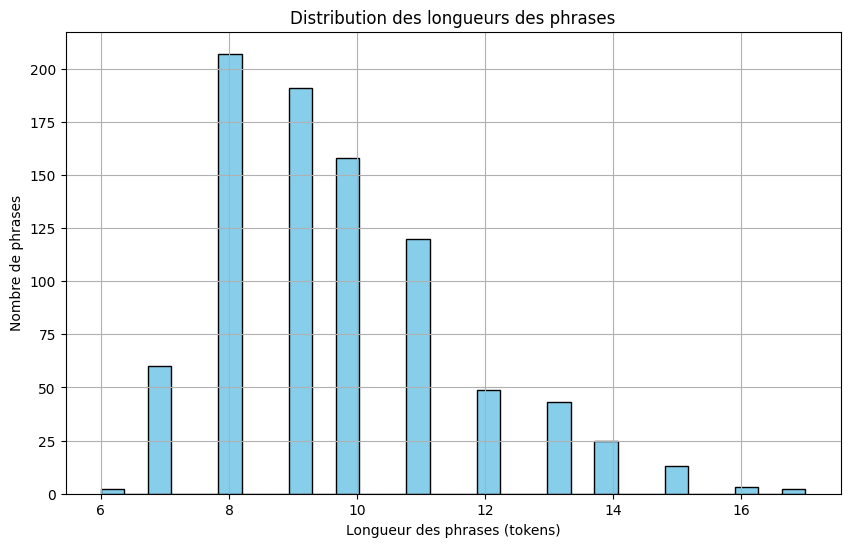

In [7]:

import matplotlib.pyplot as plt

# Calculer les longueurs des phrases
sentence_lengths = [len(text.split()) for text in test_texts]

# Tracer l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(sentence_lengths, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Longueur des phrases (tokens)")
plt.ylabel("Nombre de phrases")
plt.title("Distribution des longueurs des phrases")
plt.grid()
plt.show()
